In [1]:
print("Hello Diya")

Hello Diya


Matplotlib is building the font cache; this may take a moment.


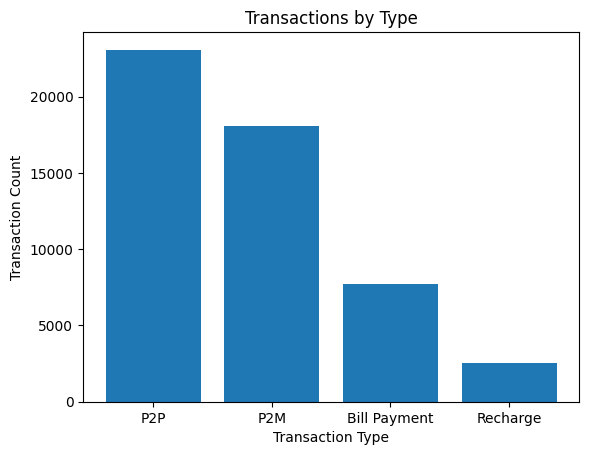

In [2]:
import matplotlib.pyplot as plt

transaction_types = ["P2P", "P2M", "Bill Payment", "Recharge"]
counts = [23087, 18057, 7735, 2527]

plt.bar(transaction_types, counts)

plt.title("Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Count")

plt.show()

In [4]:
import pandas as pd

data = {
    "Transaction Type": ["P2P", "P2M", "Bill Payment", "Recharge"],
    "Count": [23087, 18057, 7735, 2527]
}

df = pd.DataFrame(data)

df

,Transaction Type,Count
0,P2P,23087
1,P2M,18057
2,Bill Payment,7735
3,Recharge,2527


In [5]:
df.sort_values(by="Count", ascending=False)

,Transaction Type,Count
0,P2P,23087
1,P2M,18057
2,Bill Payment,7735
3,Recharge,2527


In [6]:
df[df["Count"] > 10000]

,Transaction Type,Count
0,P2P,23087
1,P2M,18057


In [7]:
df["Percentage"] = (df["Count"] / df["Count"].sum()) * 100

df

,Transaction Type,Count,Percentage
0,P2P,23087,44.911100
1,P2M,18057,35.126250
2,Bill Payment,7735,15.046882
3,Recharge,2527,4.915769


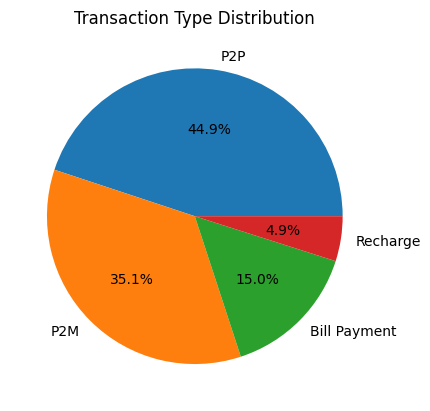

In [8]:
import matplotlib.pyplot as plt

plt.pie(
    df["Percentage"],
    labels=df["Transaction Type"],
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.show()

In [11]:
import os

os.getcwd()

'C:\\Users\\Diya K'

In [12]:
import os

os.listdir()

['.arduinoIDE',
 '.bash_history',
 '.docker',
 '.eclipse',
 '.git-for-windows-updater',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.m2',
 '.matplotlib',
 '.p2',
 '.trae',
 '.trae-aicc',
 '.vscode',
 'ai_completion',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'DownloadHelper CoApp',
 'Downloads',
 'dwhelper',
 'eclipse',
 'eclipse-workspace',
 'Favorites',
 'first_program.py',
 'htmlCSS',
 'Links',
 'Local Settings',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'node_modules',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{ba73ea77-d0e3-11ef-a85a-a0a125d2d7ae}.TM.blf',
 'NTUSER.DAT{ba73ea77-d0e3-11ef-a85a-a0a125d2d7ae}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{ba73ea77-d0e3-11ef-a85a-a0a125d2d7ae}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'package-lock.json',
 'package.json',
 'Pictures',
 'PrintHood',
 'PycharmProjects',
 'Recent',
 'Saved Games',
 'Search

In [15]:
df.shape

(250000, 17)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   transaction id      250000 non-null  str  
 1   timestamp           250000 non-null  str  
 2   transaction type    250000 non-null  str  
 3   merchant_category   250000 non-null  str  
 4   amount (INR)        250000 non-null  int64
 5   transaction_status  250000 non-null  str  
 6   sender_age_group    250000 non-null  str  
 7   receiver_age_group  250000 non-null  str  
 8   sender_state        250000 non-null  str  
 9   sender_bank         250000 non-null  str  
 10  receiver_bank       250000 non-null  str  
 11  device_type         250000 non-null  str  
 12  network_type        250000 non-null  str  
 13  fraud_flag          250000 non-null  int64
 14  hour_of_day         250000 non-null  int64
 15  day_of_week         250000 non-null  str  
 16  is_weekend          250000 non-

In [17]:
df["fraud_flag"].value_counts()

fraud_flag
0    249520
1       480
Name: count, dtype: int64

In [18]:
df["fraud_flag"].value_counts(normalize=True)*100

fraud_flag
0    99.808
1     0.192
Name: proportion, dtype: float64

In [20]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='str')

In [21]:
df["transaction type"].value_counts()

transaction type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64

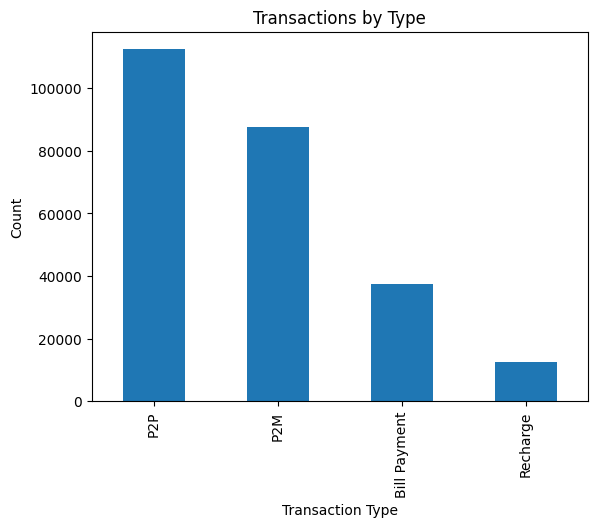

In [22]:
import matplotlib.pyplot as plt

df["transaction type"].value_counts().plot(kind="bar")

plt.title("Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

In [23]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
       'amount_(INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='str')

In [24]:
fraud_by_type = pd.crosstab(
    df["transaction_type"],
    df["fraud_flag"]
)

fraud_by_type

fraud_flag,0,1
transaction_type,,
Bill Payment,37291,77
P2M,87493,167
P2P,112239,206
Recharge,12497,30


In [25]:
fraud_rate = pd.crosstab(
    df["transaction_type"],
    df["fraud_flag"],
    normalize="index"
) * 100

fraud_rate

fraud_flag,0,1
transaction_type,,
Bill Payment,99.793941,0.206059
P2M,99.809491,0.190509
P2P,99.816799,0.183201
Recharge,99.760517,0.239483


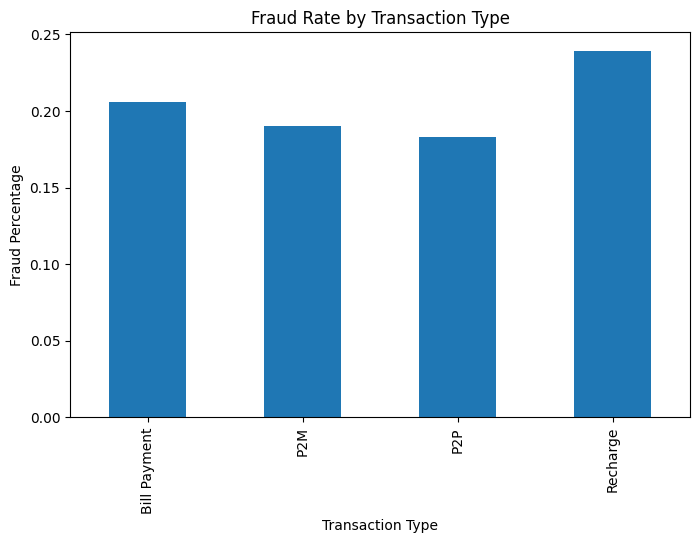

In [26]:
fraud_rate[1].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Percentage")
plt.xlabel("Transaction Type")
plt.show()

In [28]:
fraud_rate.sort_values(by=1, ascending=False)

fraud_flag,0,1
transaction_type,,
Recharge,99.760517,0.239483
Bill Payment,99.793941,0.206059
P2M,99.809491,0.190509
P2P,99.816799,0.183201


In [29]:
age_fraud = pd.crosstab(
    df["sender_age_group"],
    df["fraud_flag"],
    normalize="index"
) * 100

age_fraud

fraud_flag,0,1
sender_age_group,,
18-25,99.770631,0.229369
26-35,99.813569,0.186431
36-45,99.815501,0.184499
46-55,99.875206,0.124794
56+,99.784155,0.215845


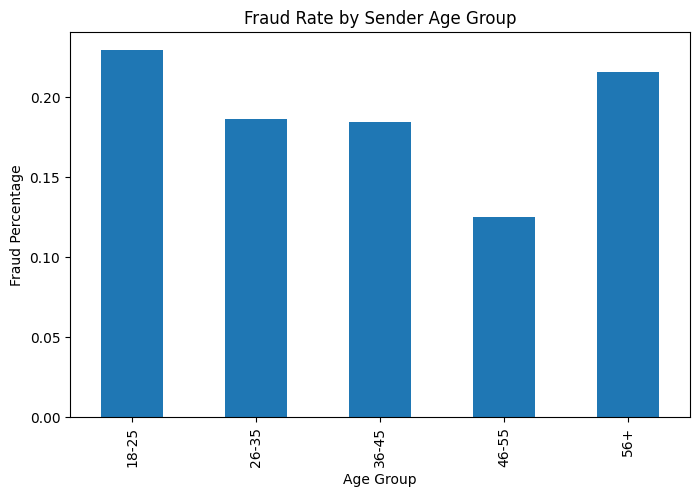

In [30]:
age_fraud[1].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Rate by Sender Age Group")
plt.ylabel("Fraud Percentage")
plt.xlabel("Age Group")
plt.show()

In [31]:
hour_fraud = df.groupby("hour_of_day")["fraud_flag"].mean() * 100

hour_fraud

hour_of_day
0     0.236128
1     0.267380
2     0.178042
3     0.304414
4     0.080192
5     0.057405
6     0.142816
7     0.230906
8     0.215595
9     0.191388
10    0.143843
11    0.165360
12    0.171272
13    0.166246
14    0.183054
15    0.253485
16    0.221555
17    0.201745
18    0.154506
19    0.202524
20    0.199935
21    0.215345
22    0.245622
23    0.154719
Name: fraud_flag, dtype: float64

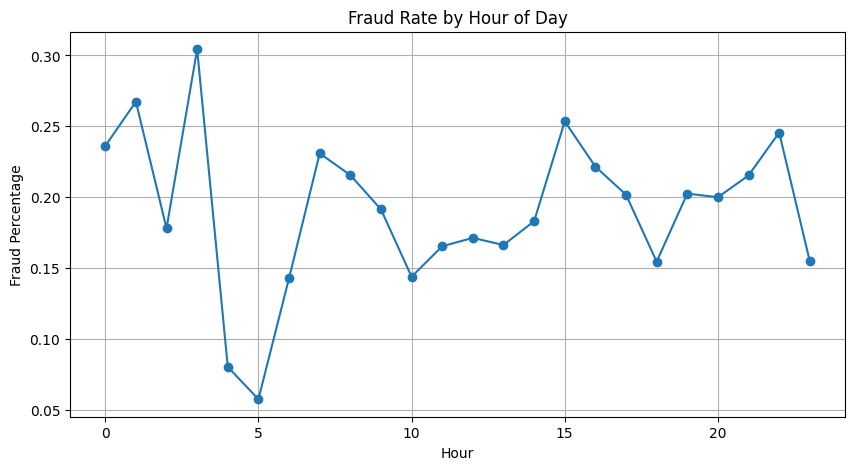

In [32]:
hour_fraud.plot(
    kind="line",
    figsize=(10,5),
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.ylabel("Fraud Percentage")
plt.xlabel("Hour")
plt.grid(True)
plt.show()

In [33]:
df["sender_bank"].value_counts().head(10)

sender_bank
SBI         62693
HDFC        37485
ICICI       29769
IndusInd    25173
Axis        25042
PNB         24946
Yes Bank    24860
Kotak       20032
Name: count, dtype: int64

In [34]:
bank_fraud = pd.crosstab(
    df["sender_bank"],
    df["fraud_flag"],
    normalize="index"
) * 100

bank_fraud.sort_values(by=1, ascending=False)

fraud_flag,0,1
sender_bank,,
Kotak,99.750399,0.249601
ICICI,99.778293,0.221707
PNB,99.791550,0.208450
IndusInd,99.793429,0.206571
Axis,99.804329,0.195671
SBI,99.826137,0.173863
HDFC,99.834601,0.165399
Yes Bank,99.839099,0.160901


In [35]:
state_fraud = pd.crosstab(
    df["sender_state"],
    df["fraud_flag"],
    normalize="index"
) * 100

state_fraud.sort_values(by=1, ascending=False)

fraud_flag,0,1
sender_state,,
Karnataka,99.768114,0.231886
Rajasthan,99.769781,0.230219
Gujarat,99.785654,0.214346
Delhi,99.798955,0.201045
Maharashtra,99.810297,0.189703
West Bengal,99.824755,0.175245
Andhra Pradesh,99.825052,0.174948
Telangana,99.826164,0.173836
Uttar Pradesh,99.827386,0.172614


In [36]:
merchant_fraud = pd.crosstab(
    df["merchant_category"],
    df["fraud_flag"],
    normalize="index"
) * 100

merchant_fraud.sort_values(by=1, ascending=False)

fraud_flag,0,1
merchant_category,,
Transport,99.786123,0.213877
Education,99.789418,0.210582
Shopping,99.792448,0.207552
Other,99.798614,0.201386
Entertainment,99.801025,0.198975
Food,99.805146,0.194854
Fuel,99.808483,0.191517
Grocery,99.811872,0.188128
Healthcare,99.834163,0.165837
